# Carga de libreria

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# Carga de base

Base de prueba despues cambiar

In [38]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Analizamos el target

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


La variable ID tiene valores distintos iguales al numero de filas, la variable "Total Charges" tiene demasiados valores distintso para ser una categorica

In [13]:
df["TotalCharges"].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

Es un numero que se esta interpretando como texto 

In [50]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [17]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [20]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Solo hay 11 missings en la variable totalcharge

COmo son pocos los eliminamos, ya luego veremos q hacer con otras bases

In [51]:
df = df.dropna()

No parece haber nada mas que sea evidente

eliminamos la columna ID para empezar

In [ ]:
df = df.drop(columns=["customerID"])

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# univariado

## Categoricas

In [24]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [25]:
len(categorical_cols)

16

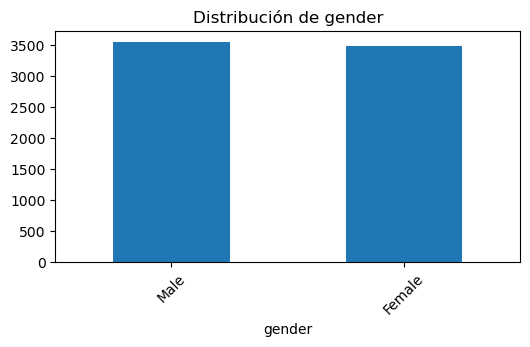

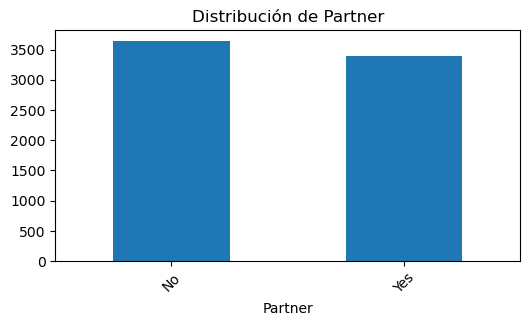

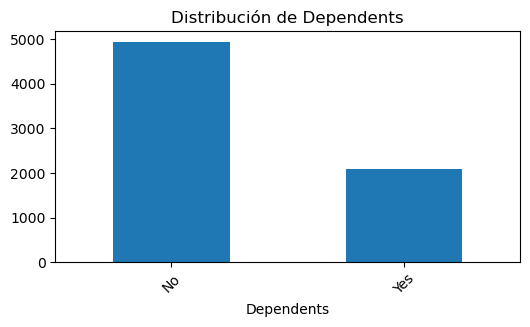

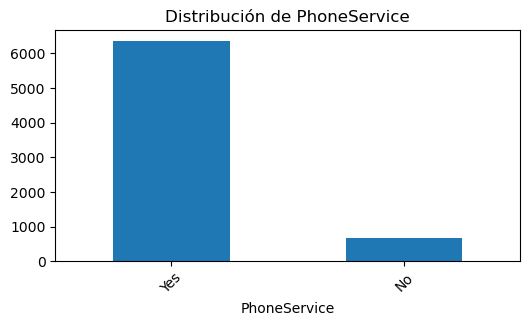

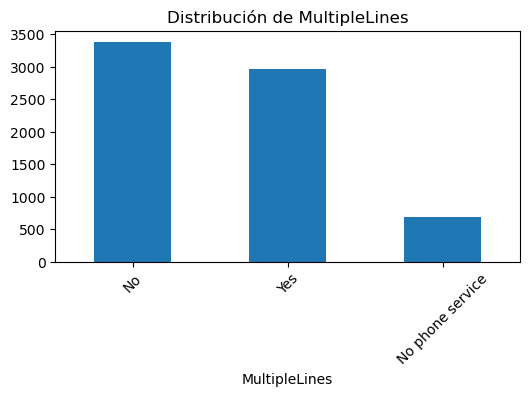

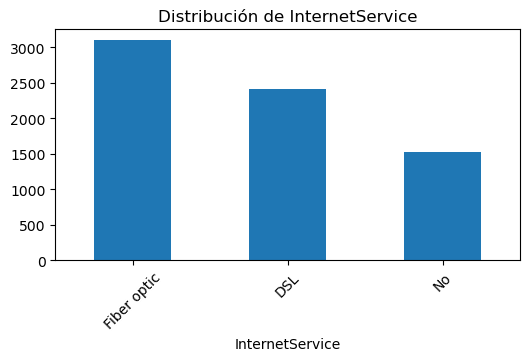

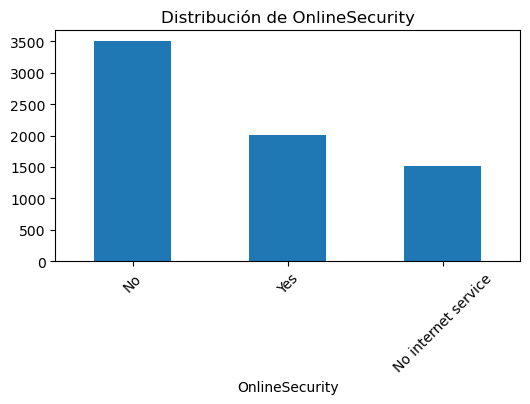

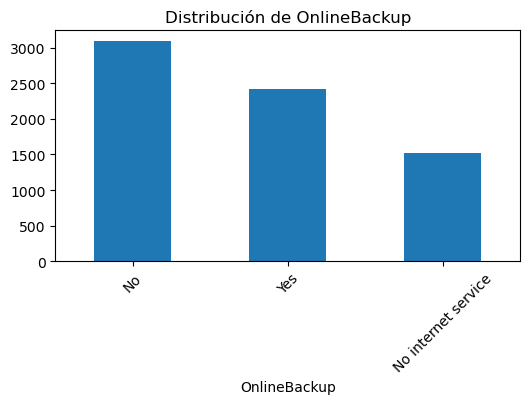

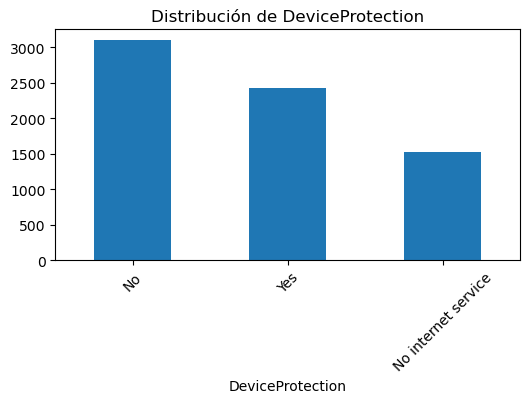

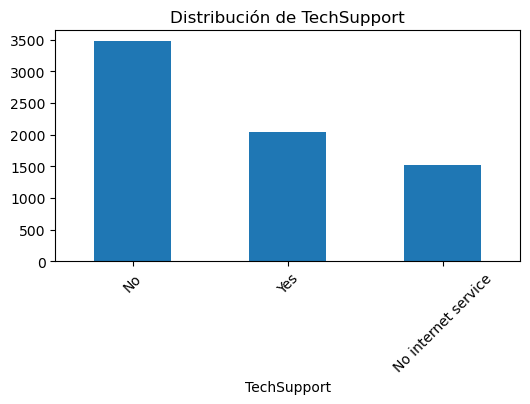

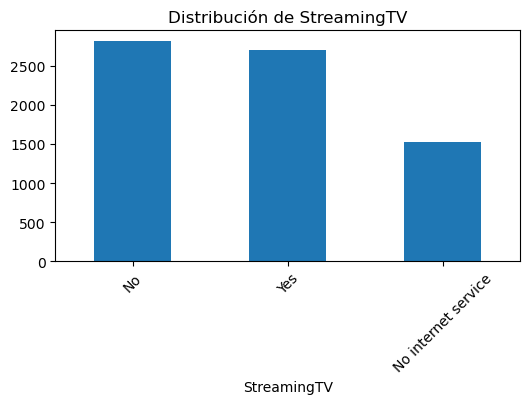

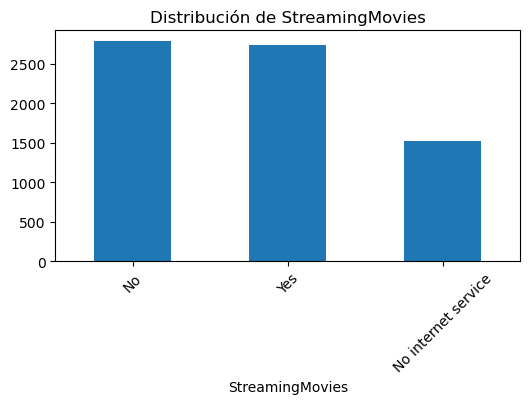

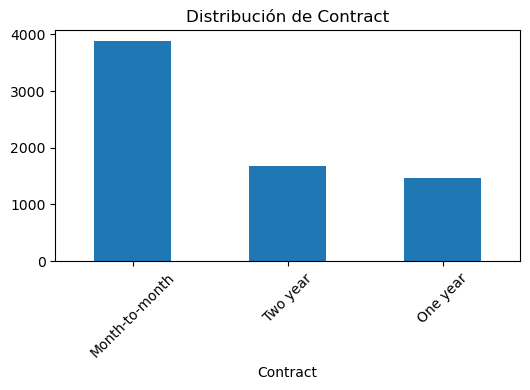

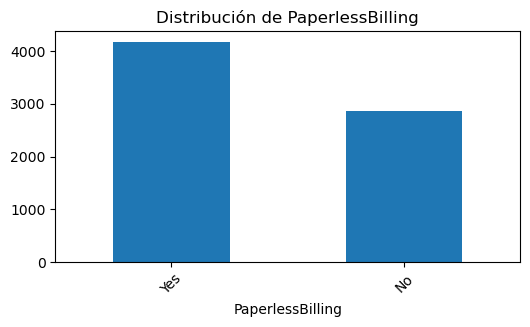

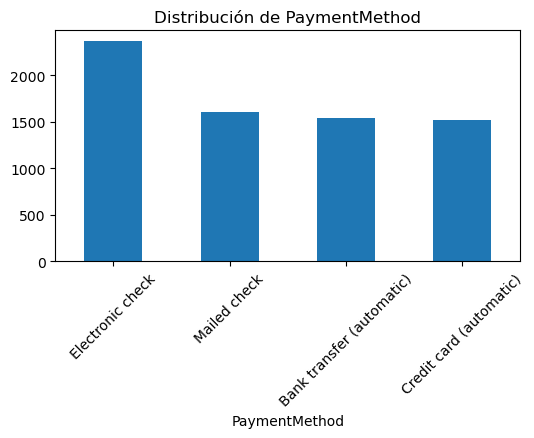

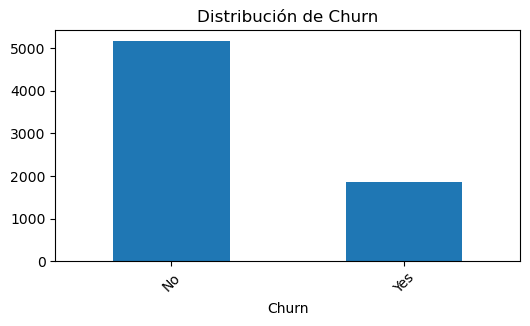

In [26]:
for col in categorical_cols:
    
    plt.figure(figsize=(6,3))
    
    df[col].value_counts().plot(kind="bar")
    
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    
    plt.show()

## Numericas

In [53]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

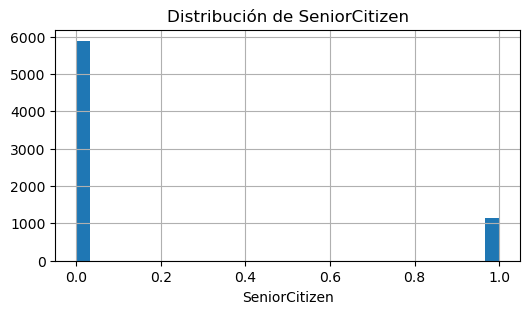

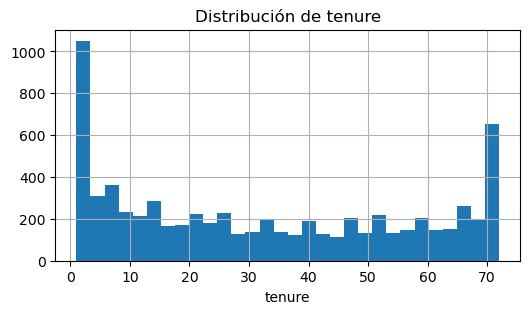

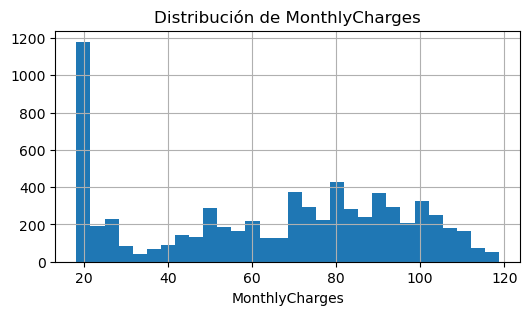

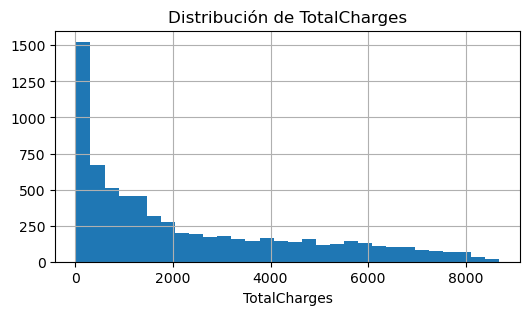

In [28]:
for col in numerical_cols:
    
    plt.figure(figsize=(6,3))
    
    df[col].hist(bins=30)
    
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    
    plt.show()

Senior Citizen solo tiene solo dos vaslores le haremos su grafico aparte.

In [31]:
#Info de Kaggle
diccionario_variables = {
    "customerID": "Identificador unico del cliente",
    "gender": "Género del cliente",
    "SeniorCitizen": "Indica si el cliente es adulto mayor (1=Si, 0=No)",
    "Partner": "Indica si el cliente tiene pareja",
    "Dependents": "Indica si el cliente tiene dependientes",
    "tenure": "Cantidad de meses que el cliente ha permanecido",
    "PhoneService": "Servicio telefónico contratado",
    "MultipleLines": "Multiples líneas telefónicas",
    "InternetService": "Tipo de servicio de internet",
    "OnlineSecurity": "Servicio de seguridad online",
    "OnlineBackup": "Servicio de respaldo online",
    "DeviceProtection": "Protección de dispositivos",
    "TechSupport": "Soporte técnico",
    "StreamingTV": "Servicio de TV streaming",
    "StreamingMovies": "Servicio de películas streaming",
    "Contract": "Tipo de contrato",
    "PaperlessBilling": "Facturación digital",
    "PaymentMethod": "Metodo de pago",
    "MonthlyCharges": "Cargo mensual del cliente",
    "TotalCharges": "Cargo total acumulado",
    "Churn": "Variable objetivo: abandono del cliente"
}

In [41]:
df["SeniorCitizen"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: SeniorCitizen
Non-Null Count  Dtype
--------------  -----
7043 non-null   int64
dtypes: int64(1)
memory usage: 55.2 KB


In [42]:
df["SeniorCitizen"] = df["SeniorCitizen"].astype(str)

df["SeniorCitizen"] = df["SeniorCitizen"].map({
    "0": "No",
    "1": "Sí"
})

In [43]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,Sí,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [44]:
df["SeniorCitizen"].head()

0    No
1    No
2    No
3    No
4    No
Name: SeniorCitizen, dtype: object

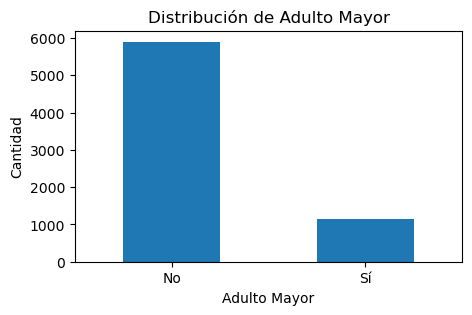

In [45]:
plt.figure(figsize=(5,3))

df["SeniorCitizen"].value_counts().plot(kind="bar")

plt.title("Distribución de Adulto Mayor")
plt.xlabel("Adulto Mayor")
plt.ylabel("Cantidad")

plt.xticks(rotation=0)

plt.show()

In [55]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

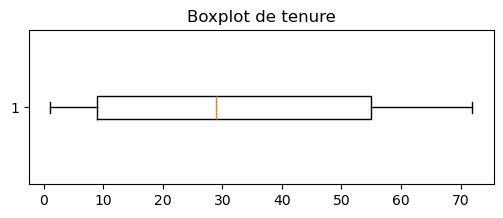

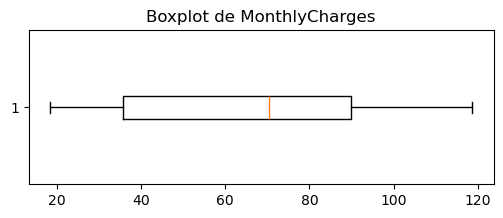

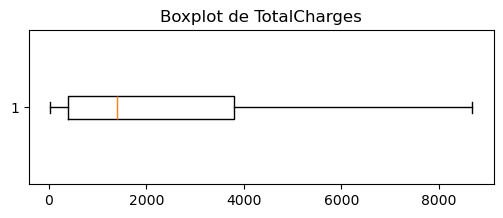

In [54]:
for col in numerical_cols:
    
    plt.figure(figsize=(6,2))
    
    plt.boxplot(df[col], vert=False)
    
    plt.title(f"Boxplot de {col}")
    
    plt.show()

## Outliers
No parece tener pero asemos funcioens rapidas

In [57]:
resumen_outliers = []

for col in numerical_cols:
    
    q1 = df[col].quantile(0.25)
    q50 = df[col].quantile(0.50)
    q75 = df[col].quantile(0.75)
    q95 = df[col].quantile(0.95)
    q99 = df[col].quantile(0.99)
    
    iqr = q75 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q75 + 1.5 * iqr
    
    outliers = (
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    ).sum()
    
    ratio_max_p99 = (
        df[col].max() / q99
        if q99 != 0 else np.nan
    )
    
    resumen_outliers.append({
        "Variable": col,
        "Min": round(df[col].min(),2),
        "P1": round(df[col].quantile(0.01),2),
        "P25": round(q1,2),
        "P50": round(q50,2),
        "P75": round(q75,2),
        "P95": round(q95,2),
        "P99": round(q99,2),
        "Max": round(df[col].max(),2),
        "IQR": round(iqr,2),
        "Límite Superior": round(limite_superior,2),
        "N° Outliers": outliers,
        "% Outliers": round(
            outliers / len(df) * 100,
            2
        ),
        "Ratio Max/P99": round(
            ratio_max_p99,
            2
        )
    })

tabla_outliers = pd.DataFrame(
    resumen_outliers
)

tabla_outliers

,Variable,Min,P1,P25,P50,P75,P95,P99,Max,IQR,Límite Superior,N° Outliers,% Outliers,Ratio Max/P99
0,tenure,1.00,1.0,9.00,29.00,55.00,72.00,72.00,72.00,46.00,124.00,0,0.0,1.00
1,MonthlyCharges,18.25,19.2,35.59,70.35,89.86,107.42,114.73,118.75,54.28,171.27,0,0.0,1.03
2,TotalCharges,18.80,19.9,401.45,1397.48,3794.74,6923.59,8039.88,8684.80,3393.29,8884.67,0,0.0,1.08


Por el IQR n o parecen haber outliers y no hay mucha diferencia entre el maximo y el percentil 99 

## Bivraiado

Para el bivariado ( Gini) necesitamos primero hacer que las categoricas se vuelvan ordinales, por algun sentido de negocio

In [ ]:
Pero pr

In [61]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

In [59]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

C:\Users\Rhend\AppData\Local\Temp\ipykernel_3488\3695867824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Churn"] = df["Churn"].map({
